# Vineyard Row Metrics Visualization

Visualizes outputs from `row_features.parquet` and `row_canopy_structure.parquet`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

plt.rcParams.update({"figure.dpi": 110, "figure.facecolor": "white"})

DATA_DIR = "out_cluster_las"

rf = pd.read_parquet(f"{DATA_DIR}/row_features.parquet")
cs = pd.read_parquet(f"{DATA_DIR}/row_canopy_structure.parquet")
df = rf.merge(cs, on=["cluster_file", "row_id"], suffixes=("_rf", "_cs"))

print(f"row_features:          {len(rf)} rows, {len(rf.columns)} cols")
print(f"row_canopy_structure:  {len(cs)} rows, {len(cs.columns)} cols")
print(f"merged:                {len(df)} rows")

row_features:          49 rows, 37 cols
row_canopy_structure:  49 rows, 27 cols
merged:                49 rows


## 1. Row Features Overview

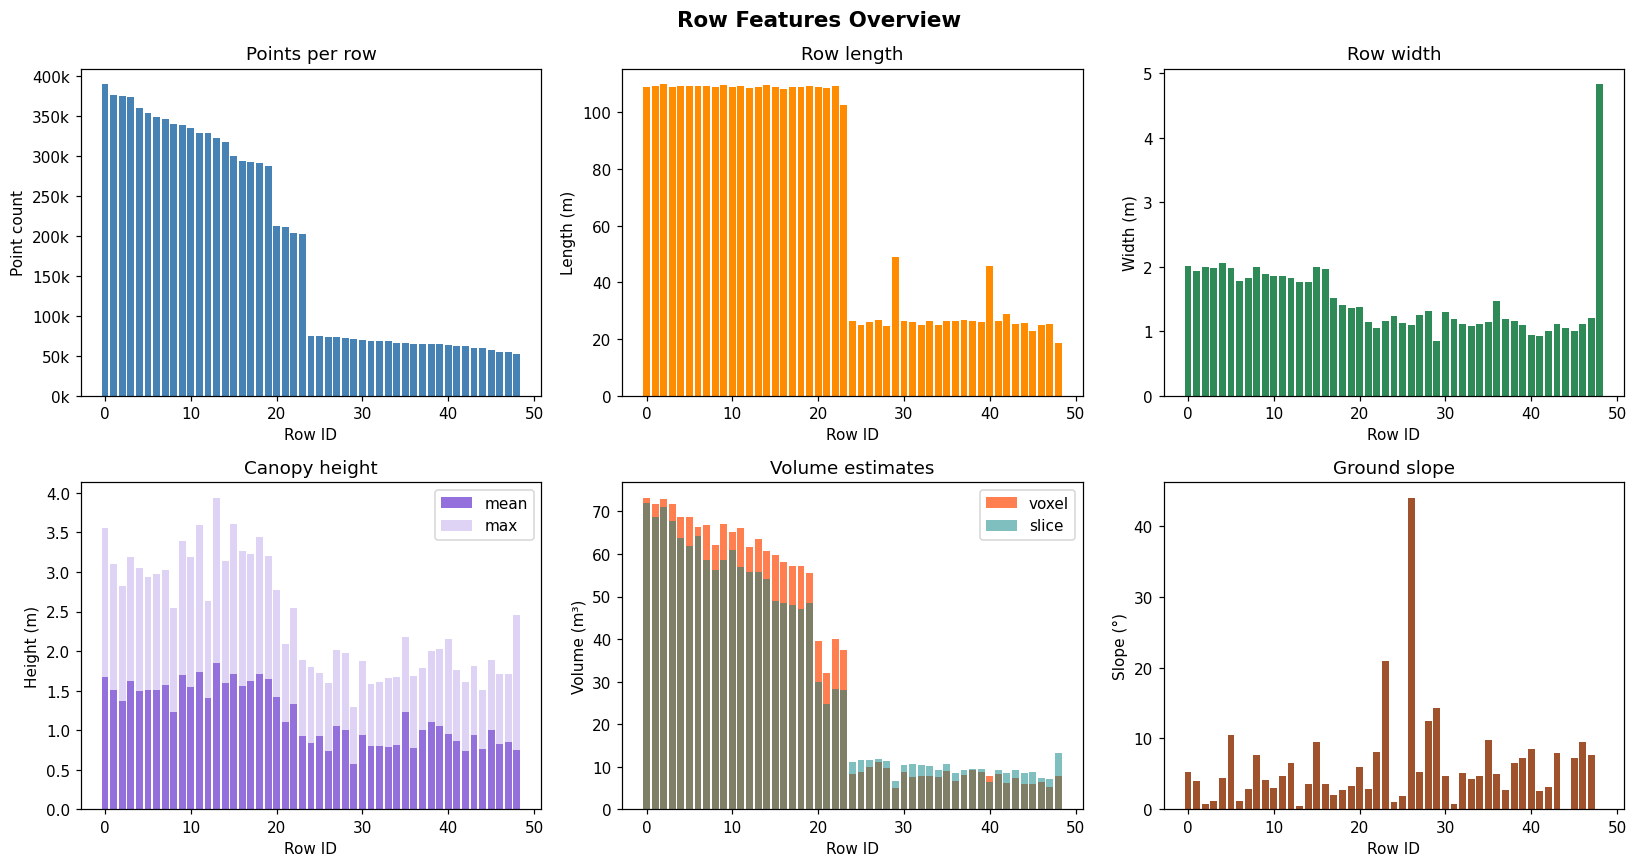

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

ax = axes[0, 0]
ax.bar(rf["row_id"], rf["point_count"], color="steelblue")
ax.set_xlabel("Row ID")
ax.set_ylabel("Point count")
ax.set_title("Points per row")
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))

ax = axes[0, 1]
ax.bar(rf["row_id"], rf["row_length"], color="darkorange")
ax.set_xlabel("Row ID")
ax.set_ylabel("Length (m)")
ax.set_title("Row length")

ax = axes[0, 2]
ax.bar(rf["row_id"], rf["row_width"], color="seagreen")
ax.set_xlabel("Row ID")
ax.set_ylabel("Width (m)")
ax.set_title("Row width")

ax = axes[1, 0]
ax.bar(rf["row_id"], rf["height_mean"], color="mediumpurple", label="mean")
ax.bar(rf["row_id"], rf["height_max"], color="mediumpurple", alpha=0.3, label="max")
ax.set_xlabel("Row ID")
ax.set_ylabel("Height (m)")
ax.set_title("Canopy height")
ax.legend()

ax = axes[1, 1]
ax.bar(rf["row_id"], rf["vol_voxel"], color="coral", label="voxel")
ax.bar(rf["row_id"], rf["vol_slice"], color="teal", alpha=0.5, label="slice")
ax.set_xlabel("Row ID")
ax.set_ylabel("Volume (m³)")
ax.set_title("Volume estimates")
ax.legend()

ax = axes[1, 2]
ax.bar(rf["row_id"], rf["ground_slope_deg"], color="sienna")
ax.set_xlabel("Row ID")
ax.set_ylabel("Slope (°)")
ax.set_title("Ground slope")

fig.suptitle("Row Features Overview", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

## 2. NDVI Statistics

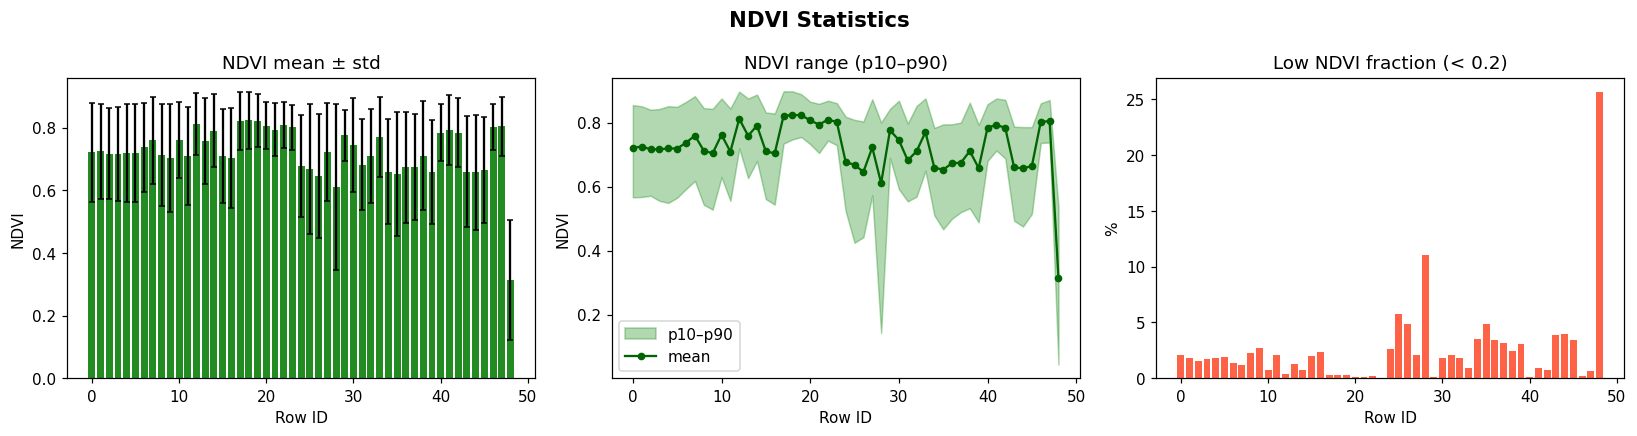

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.bar(rf["row_id"], rf["ndvi_mean"], color="forestgreen", yerr=rf["ndvi_std"], capsize=2)
ax.set_xlabel("Row ID")
ax.set_ylabel("NDVI")
ax.set_title("NDVI mean ± std")

ax = axes[1]
ax.fill_between(rf["row_id"], rf["ndvi_p10"], rf["ndvi_p90"], alpha=0.3, color="green", label="p10–p90")
ax.plot(rf["row_id"], rf["ndvi_mean"], "o-", color="darkgreen", ms=4, label="mean")
ax.set_xlabel("Row ID")
ax.set_ylabel("NDVI")
ax.set_title("NDVI range (p10–p90)")
ax.legend()

ax = axes[2]
ax.bar(rf["row_id"], rf["ndvi_low_frac"] * 100, color="tomato")
ax.set_xlabel("Row ID")
ax.set_ylabel("%")
ax.set_title("Low NDVI fraction (< 0.2)")

fig.suptitle("NDVI Statistics", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

## 3. Canopy Structure — Porosity & Gap Fraction

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

ax = axes[0, 0]
ax.bar(cs["row_id"], cs["porosity_mean"], color="slategray")
ax.set_xlabel("Row ID")
ax.set_ylabel("Porosity (mean)")
ax.set_title("Segment porosity (mean)")

ax = axes[0, 1]
ax.plot(cs["row_id"], cs["porosity_mean"], "o-", ms=4, label="mean")
ax.plot(cs["row_id"], cs["porosity_p50"], "s-", ms=4, label="p50")
ax.plot(cs["row_id"], cs["porosity_p90"], "^-", ms=4, label="p90")
ax.set_xlabel("Row ID")
ax.set_ylabel("Porosity")
ax.set_title("Segment porosity distribution")
ax.legend()

ax = axes[1, 0]
ax.bar(cs["row_id"], cs["gap_fraction_mean"], color="sandybrown", label="mean")
ax.set_xlabel("Row ID")
ax.set_ylabel("Gap fraction (mean)")
ax.set_title("Segment gap fraction (mean)")

ax = axes[1, 1]
ax.plot(cs["row_id"], cs["gap_fraction_mean"], "o-", ms=4, label="mean")
ax.plot(cs["row_id"], cs["gap_fraction_p50"], "s-", ms=4, label="p50")
ax.plot(cs["row_id"], cs["gap_fraction_p90"], "^-", ms=4, label="p90")
ax.set_xlabel("Row ID")
ax.set_ylabel("Gap fraction")
ax.set_title("Segment gap fraction distribution")
ax.legend()

fig.suptitle("Canopy Structure — Segment-based Porosity & Gap Fraction", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

## 4. LAI & LAD Proxies

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.bar(cs["row_id"], cs["lai_proxy_mean"], color="olivedrab")
ax.set_xlabel("Row ID")
ax.set_ylabel("LAI proxy (mean)")
ax.set_title("Segment LAI proxy (mean)")

ax = axes[1]
ax.bar(cs["row_id"], cs["lad_proxy_mean"], color="darkkhaki", label="mean")
ax.set_xlabel("Row ID")
ax.set_ylabel("LAD proxy (mean)")
ax.set_title("Segment LAD proxy (mean)")

ax = axes[2]
ax.plot(cs["row_id"], cs["lad_proxy_mean"], "o-", ms=4, label="mean")
ax.plot(cs["row_id"], cs["lad_proxy_p50"], "s-", ms=4, label="p50")
ax.plot(cs["row_id"], cs["lad_proxy_p90"], "^-", ms=4, label="p90")
ax.set_xlabel("Row ID")
ax.set_ylabel("LAD proxy")
ax.set_title("Segment LAD proxy distribution")
ax.legend()

fig.suptitle("LAI & LAD Proxies (segment-aggregated)", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

## 5. Cross-metric Correlations

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

ax = axes[0, 0]
ax.scatter(df["ndvi_mean"], df["lai_proxy_mean"], c=df["row_id"], cmap="viridis", edgecolors="k", lw=0.3)
ax.set_xlabel("NDVI mean")
ax.set_ylabel("LAI proxy (mean)")
ax.set_title("NDVI vs LAI proxy")

ax = axes[0, 1]
ax.scatter(df["vol_voxel"], df["porosity_mean"], c=df["row_id"], cmap="viridis", edgecolors="k", lw=0.3)
ax.set_xlabel("Voxel volume (m³)")
ax.set_ylabel("Porosity (mean)")
ax.set_title("Volume vs porosity")

ax = axes[1, 0]
ax.scatter(df["height_mean"], df["lad_proxy_mean"], c=df["row_id"], cmap="viridis", edgecolors="k", lw=0.3)
ax.set_xlabel("Mean height (m)")
ax.set_ylabel("LAD proxy (mean)")
ax.set_title("Height vs LAD proxy")

ax = axes[1, 1]
sc = ax.scatter(df["gap_fraction_mean"], df["ndvi_mean"], c=df["row_id"], cmap="viridis", edgecolors="k", lw=0.3)
ax.set_xlabel("Gap fraction (mean)")
ax.set_ylabel("NDVI mean")
ax.set_title("Gap fraction vs NDVI")
fig.colorbar(sc, ax=ax, label="Row ID")

fig.suptitle("Cross-metric Correlations", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

## 6. Correlation Heatmap

In [ ]:
cols = [
    "point_count_rf", "row_length", "row_width", "height_mean", "height_max",
    "vol_voxel", "vol_slice", "ndvi_mean", "ndvi_range",
    "porosity_mean", "gap_fraction_mean",
    "lai_proxy_mean", "lad_proxy_mean",
]
corr = df[cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
labels = [c.replace("_rf", "") for c in cols]
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(labels, fontsize=9)

for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)

fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

## 7. Summary Tables

In [8]:
print("=== Row Features (key columns) ===")
rf_show = ["row_id", "point_count", "row_length", "row_width",
           "height_mean", "height_max", "vol_voxel", "vol_slice",
           "ndvi_mean", "ndvi_range", "ground_slope_deg"]
display(rf[rf_show].describe().round(3))

=== Row Features (key columns) ===


,row_id,point_count,row_length,row_width,height_mean,height_max,vol_voxel,vol_slice,ndvi_mean,ndvi_range,ground_slope_deg
count,49.000,49.000,49.000,49.000,49.000,49.000,49.000,49.000,49.000,49.000,49.000
mean,24.000,186971.102,67.236,1.496,1.192,2.412,33.429,30.986,0.723,0.259,6.030
std,14.289,131472.700,41.472,0.618,0.365,0.731,27.682,24.021,0.083,0.097,6.824
min,0.000,51555.000,18.526,0.844,0.567,1.293,5.036,6.324,0.314,0.124,0.068
25%,12.000,65264.000,26.174,1.112,0.855,1.760,7.755,9.383,0.677,0.177,2.690
50%,24.000,74734.000,48.908,1.297,1.107,2.158,11.057,13.111,0.719,0.273,4.633
75%,36.000,328622.000,109.065,1.850,1.543,3.097,62.180,55.873,0.784,0.294,7.684
max,48.000,389691.000,109.917,4.828,1.846,3.940,73.232,71.899,0.824,0.657,44.040


In [ ]:
print("=== Canopy Structure (key columns) ===")
cs_show = ["row_id", "n_segments_total", "n_segments_valid",
           "porosity_mean", "porosity_p50",
           "gap_fraction_mean", "gap_fraction_p50",
           "lai_proxy_mean", "lai_proxy_p50",
           "lad_proxy_mean", "lad_proxy_p50",
           "height_range"]
display(cs[cs_show].describe().round(4))